## Notebook de entrenamiento de modelo yolo

PARA EXTRAER CUADRICULA SUDOKU

### Opción para google colabs.

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
import matplotlib.pyplot as plt
import cv2
import torch
from ultralytics import YOLO
import os
#from google.colab import files

In [2]:
modelo = YOLO('yolov8n.pt') 
#version más ligera sin segmentacion, no lo necesito para sacar cuadricula sudoku
#creamos objeto con los métodos asociados

In [8]:
modelo.train(
    # Archivo yaml para definir el dataset.
    data="data.yaml",
    epochs=30,  # Numero de epocas que defino.
    batch=64,   #Tamaño de batch. RECOMENDABLE MULTIPLOS DE 8
    imgsz=640,  # Tamaño de las imagenes.
    project="sudoku",  # Carpeta donde se guardará el entrenamiento.
    name="sudoku",  # Nombre del modelo.
    save=True,      # Guardar el modelo después de entrenar.
    exist_ok=True   # Sobrescribir resultados si ya existe una carpeta.
)

New https://pypi.org/project/ultralytics/8.4.71 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.69  Python-3.12.10 torch-2.12.0+cpu CPU (AMD Ryzen 7 7730U with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=sudoku, nb

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001A652C2A3C0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

In [9]:
results = modelo.val()  # Evalúa el modelo en el conjunto de validación
print(results)

Ultralytics 8.4.69  Python-3.12.10 torch-2.12.0+cpu CPU (AMD Ryzen 7 7730U with Radeon Graphics)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 145.5176.3 MB/s, size: 242.8 KB)
val: Scanning C:\Users\Miboo\Desktop\Bootcamp\Mi_trabajo\Mis_Proyectos\Proyecto_RRNN\1_Modelo_Yolo\img\labels\val.cache... 21 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 21/21  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.1s/it 2.1s4.3s
                   all         21         21      0.997          1      0.995      0.987
Speed: 1.8ms preprocess, 70.8ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to C:\Users\Miboo\Desktop\Bootcamp\Mi_trabajo\Mis_Proyectos\Proyecto_RRNN\1_Modelo_Yolo\runs\detect\val-4
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric obje

## Prueba modelo con imagenes.

In [16]:
#primera deteccion
modelo = YOLO('runs/detect/sudoku/sudoku/weights/best.pt') 
img_path = "img/img_pruebas/img_1.png"

img = cv2.imread(img_path)
results = modelo(img_path) 

results[0].save()  # Guarda la imagen en la carpeta 'runs/detect/predict'


image 1/1 c:\Users\Miboo\Desktop\Bootcamp\Mi_trabajo\Mis_Proyectos\Proyecto_RRNN\Proyecto_Redes_Neuronales\img\img_pruebas\img_1.png: 544x640 1 sudoku, 87.2ms
Speed: 7.5ms preprocess, 87.2ms inference, 1.2ms postprocess per image at shape (1, 3, 544, 640)


'results_img_1.png'

In [17]:
# segunda deteccion
modelo = YOLO('runs/detect/sudoku/sudoku/weights/best.pt') 
img_path = "results_img_1.png"

img = cv2.imread(img_path)
results2 = modelo(img_path) 

results2[0].save()  # Guarda la imagen en la carpeta 'runs/detect/predict'


image 1/1 c:\Users\Miboo\Desktop\Bootcamp\Mi_trabajo\Mis_Proyectos\Proyecto_RRNN\Proyecto_Redes_Neuronales\results_img_1.png: 544x640 1 sudoku, 102.7ms
Speed: 7.7ms preprocess, 102.7ms inference, 1.2ms postprocess per image at shape (1, 3, 544, 640)


'results_results_img_1.png'

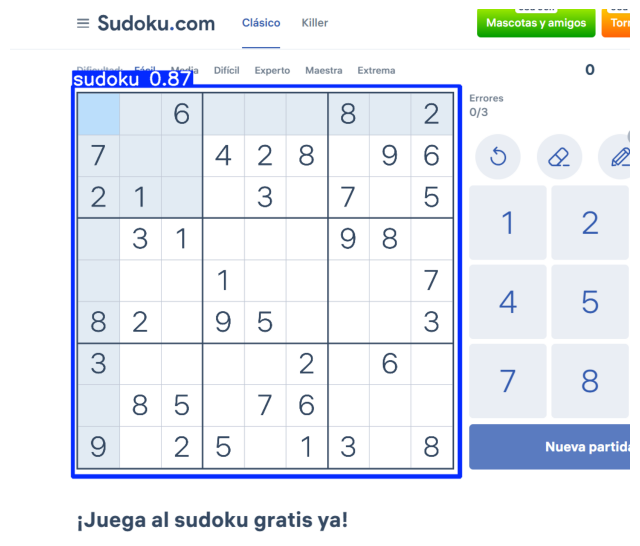

In [18]:

img = cv2.imread("results_results_img_1.png")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

In [19]:
# Obtener coordenadas de la detección

box = results2[0].boxes.xyxy[0].cpu().numpy()

x1, y1, x2, y2 = map(int, box)

print(f"x1={x1}, y1={y1}, x2={x2}, y2={y2}")

x1=104, y1=127, x2=743, y2=772


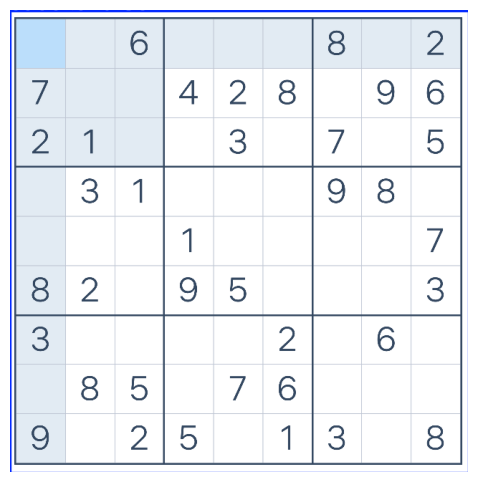

True

In [20]:
#para recortar el sudoku
img = cv2.imread(img_path)

sudoku_crop = img[y1:y2, x1:x2]

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(sudoku_crop, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

cv2.imwrite("sudoku_crop.png", sudoku_crop)

In [21]:
#segmentacion 81 celdas

def extraer_celdas(sudoku_crop, output_dir="celdas", size=450, margin=5):
    os.makedirs(output_dir, exist_ok=True)

    sudoku_resized = cv2.resize(sudoku_crop, (size, size))

    cell_size = size // 9
    cells = []

    for fila in range(9):
        row_cells = []

        for col in range(9):
            x1 = col * cell_size
            y1 = fila * cell_size
            x2 = x1 + cell_size
            y2 = y1 + cell_size

            cell = sudoku_resized[y1:y2, x1:x2]

            cell_inner = cell[margin:-margin, margin:-margin]

            filename = f"cell_{fila}_{col}.png"
            cv2.imwrite(os.path.join(output_dir, filename), cell_inner)

            row_cells.append(cell_inner)

        cells.append(row_cells)

    return cells

In [22]:
#ejecutar la funcion

cells = extraer_celdas(
    sudoku_crop=sudoku_crop,
    output_dir="celdas",
    size=450,
    margin=4
)

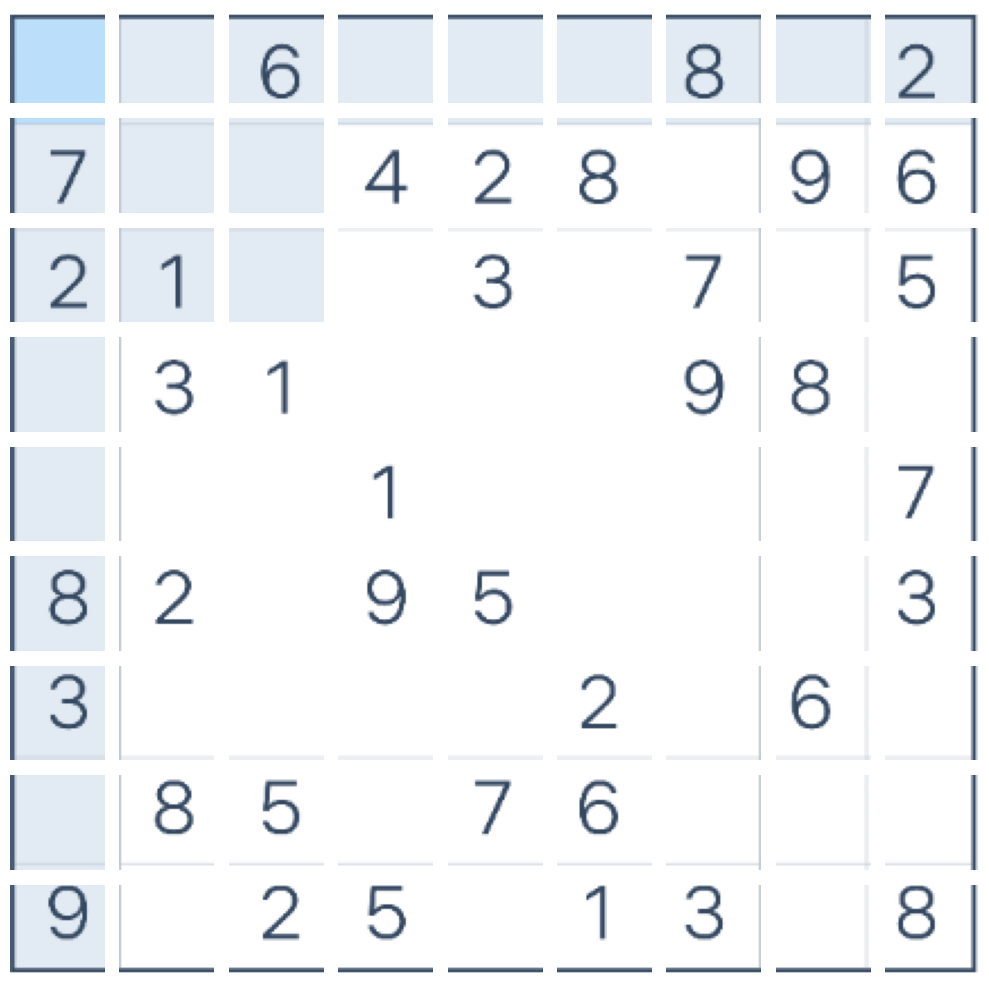

In [23]:
#visualizar la 81 celdas

plt.figure(figsize=(10, 10))

for fila in range(9):
    for col in range(9):
        plt.subplot(9, 9, fila * 9 + col + 1)

        cell_rgb = cv2.cvtColor(cells[fila][col], cv2.COLOR_BGR2RGB)

        plt.imshow(cell_rgb)
        plt.axis("off")

plt.tight_layout()
plt.show()

In [24]:
#comprobar celdas generadas

print("Número de celdas guardadas:", len(os.listdir("celdas")))
print(os.listdir("celdas")[:10])

Número de celdas guardadas: 81
['cell_0_0.png', 'cell_0_1.png', 'cell_0_2.png', 'cell_0_3.png', 'cell_0_4.png', 'cell_0_5.png', 'cell_0_6.png', 'cell_0_7.png', 'cell_0_8.png', 'cell_1_0.png']
